In [12]:
import pandas as pd

df = pd.read_excel(
    'data analyst.xlsx',
    sheet_name='HW3_transactions_20000_clean'
)

df.head()

,transaction_id,from_account_id,to_account_id,transaction_datetime,transaction_amount_thb,transaction_channel,transaction_status,from_account_province,to_account_province,transaction_hour,time_gap_prev_txn_minutes,is_mule_transaction,mule_reason
0,TXN010651,FA474555,TA140048,2025-12-25 07:13:48,608,ATM,Success,Ayutthaya,Chonburi,7,1711,0,Normal transaction
1,TXN002042,FA903208,TA975761,2026-02-04 18:09:48,35535,ATM,Success,Nonthaburi,Ayutthaya,18,4589,0,Normal transaction
2,TXN008669,FA578966,TA334576,2025-04-09 19:35:48,27376,ATM,Success,Phuket,Songkhla,19,6891,0,Normal transaction
3,TXN001115,FA408433,TA230182,2025-06-14 09:22:48,35539,Online Banking,Success,Chiang Mai,Bangkok,9,4506,0,Normal transaction
4,TXN013903,FA626489,TA610717,2025-08-01 06:46:48,12551,Mobile Banking,Success,Chiang Mai,Nonthaburi,6,4442,0,Normal transaction


In [14]:

df.shape

(20000, 13)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   transaction_id             20000 non-null  object        
 1   from_account_id            20000 non-null  object        
 2   to_account_id              20000 non-null  object        
 3   transaction_datetime       20000 non-null  datetime64[ns]
 4   transaction_amount_thb     20000 non-null  int64         
 5   transaction_channel        20000 non-null  object        
 6   transaction_status         20000 non-null  object        
 7   from_account_province      20000 non-null  object        
 8   to_account_province        20000 non-null  object        
 9   transaction_hour           20000 non-null  int64         
 10  time_gap_prev_txn_minutes  20000 non-null  int64         
 11  is_mule_transaction        20000 non-null  int64         
 12  mule

In [16]:
df.describe()

,transaction_datetime,transaction_amount_thb,transaction_hour,time_gap_prev_txn_minutes,is_mule_transaction
count,20000,20000.000000,20000.000000,20000.000000,20000.000000
mean,2025-08-05 21:53:43.802999808,27021.968950,11.465000,4929.299950,0.020000
min,2025-02-05 08:02:48,508.000000,0.000000,1.000000,0.000000
25%,2025-05-06 04:24:48,13350.000000,5.000000,2370.000000,0.000000
50%,2025-08-04 10:06:18,25913.500000,11.000000,4904.000000,0.000000
75%,2025-11-06 16:40:03,38426.250000,18.000000,7497.250000,0.000000
max,2026-02-05 07:52:48,199687.000000,23.000000,10000.000000,1.000000
std,NaN,19590.504575,7.005571,2935.876805,0.140004


In [18]:
df.isnull().sum()

,0
transaction_id,0
from_account_id,0
to_account_id,0
transaction_datetime,0
transaction_amount_thb,0
transaction_channel,0
transaction_status,0
from_account_province,0
to_account_province,0
transaction_hour,0


In [20]:
# ยอดรวมทั้งหมด
df['transaction_amount_thb'].sum()



508

In [21]:
# ค่าเฉลี่ยต่อธุรกรรม
df['transaction_amount_thb'].mean()



np.float64(27021.96895)

In [25]:

df['transaction_amount_thb'].max()


199687

In [24]:

df['transaction_amount_thb'].min()

508

In [29]:
#วิเคราะห์ตามช่องทางธุรกรรม
df.groupby('transaction_channel')['transaction_amount_thb'].agg(['count','sum','mean']).sort_values(by='sum', ascending=False)

,count,sum,mean
transaction_channel,,,
ATM,6765,181781651,26870.901848
Mobile Banking,6634,179525891,27061.484926
Online Banking,6601,179131837,27137.075746


In [30]:
#วิเคราะห์ตามสถานะธุรกรรม
df.groupby('transaction_status')['transaction_amount_thb'].agg(['count','sum'])

,count,sum
transaction_status,,
Failed,927,22677327
Success,19073,517762052


In [31]:
#วิเคราะห์จังหวัดต้นทาง
df.groupby('from_account_province')['transaction_amount_thb'].sum().sort_values(ascending=False).head(10)

,transaction_amount_thb
from_account_province,
Bangkok,63993329
Pathum Thani,63280913
Chonburi,63019731
Nonthaburi,52286582
Chiang Mai,51483109
Songkhla,50826010
Nakhon Ratchasima,49701881
Phuket,49275289
Ayutthaya,48498148


In [35]:
#จังหวัดที่มี mule สูงสุด
df[df['is_mule_transaction'] == 1] \
.groupby('from_account_province').size() \
.sort_values(ascending=False)

,0
from_account_province,
Pathum Thani,142
Bangkok,137
Chonburi,121


In [32]:
#วิเคราะห์ Mule Transaction
# จำนวนธุรกรรมที่เป็น mule
df['is_mule_transaction'].value_counts()

# เปรียบเทียบยอดเงิน mule vs ปกติ
df.groupby('is_mule_transaction')['transaction_amount_thb'].agg(['count','sum','mean'])

,count,sum,mean
is_mule_transaction,,,
0,19600,497135472,25364.054694
1,400,43303907,108259.767500


In [33]:
#วิเคราะห์ช่วงเวลาเสี่ยง
df.groupby('transaction_hour')['transaction_amount_thb'].agg(['count','sum'])

,count,sum
transaction_hour,,
0,840,25033549
1,848,25740707
2,870,25221508
3,896,27418069
4,883,25029445
5,839,25417278
6,841,20633881
7,792,20122967
8,850,21755414


In [34]:
#วิเคราะห์ time gap ก่อนหน้า
df.groupby('is_mule_transaction')['time_gap_prev_txn_minutes'].mean()

,time_gap_prev_txn_minutes
is_mule_transaction,
0,5029.787755
1,5.397500


<h1>Exploratory Analysis

In [36]:
#Mule vs Normal
df.groupby('is_mule_transaction')['transaction_amount_thb'].describe()

,count,mean,std,min,25%,50%,75%,max
is_mule_transaction,,,,,,,,
0,19600.0,25364.054694,14245.577893,508.0,13062.0,25425.5,37811.75,49995.0
1,400.0,108259.767500,50170.517695,20268.0,69925.0,106015.0,150429.25,199687.0


<H3>Insight - Mule transactions have significantly higher transaction amounts (≈4x higher on average) compared to normal transactions.

In [40]:
#Transaction Hour Pattern
df.groupby(['transaction_hour','is_mule_transaction']).size().unstack()

is_mule_transaction,0,1
transaction_hour,,
0,796.0,44.0
1,793.0,55.0
2,834.0,36.0
3,841.0,55.0
4,841.0,42.0
5,786.0,53.0
6,841.0,NaN
7,792.0,NaN
8,850.0,NaN


<h3>Insight - Mule transactions are heavily concentrated during late-night hours (22:00–05:00), indicating suspicious off-peak activity behavior.

In [38]:
#Time Gap Between Transactions
df.groupby('is_mule_transaction')['time_gap_prev_txn_minutes'].describe()

,count,mean,std,min,25%,50%,75%,max
is_mule_transaction,,,,,,,,
0,19600.0,5029.787755,2879.300484,30.0,2534.0,5007.0,7545.0,10000.0
1,400.0,5.397500,2.871429,1.0,3.0,5.0,8.0,10.0


<h3>Insight -
Mule transactions exhibit extremely short time gaps (≈5 minutes) compared to normal transactions (≈5000 minutes), suggesting rapid, structured transfers.

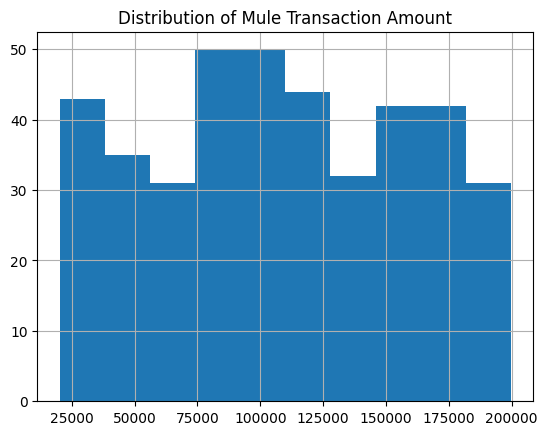

In [39]:
import matplotlib.pyplot as plt

df[df['is_mule_transaction']==1]['transaction_amount_thb'].hist()
plt.title("Distribution of Mule Transaction Amount")
plt.show()

<h1>Risk Indicator Feature

In [41]:
df['high_amount_flag'] = df['transaction_amount_thb'] > 80000
df['late_night_flag'] = df['transaction_hour'].isin([22,23,0,1,2,3,4,5])
df['short_gap_flag'] = df['time_gap_prev_txn_minutes'] < 10

<h1>Risk Score

In [44]:
df['risk_score'] = (
    df['high_amount_flag'].astype(int) +
    df['late_night_flag'].astype(int) +
    df['short_gap_flag'].astype(int)
)

In [43]:
pd.crosstab(df['risk_score'], df['is_mule_transaction'])

is_mule_transaction,0,1
risk_score,,
0,13060,0
1,6540,16
2,0,135
3,0,249


#Performance Metrics

In [45]:
from sklearn.metrics import confusion_matrix, classification_report

# สมมติว่า risk_score >= 2 คือ predicted mule
df['predicted_mule'] = df['risk_score'] >= 2

confusion_matrix(df['is_mule_transaction'], df['predicted_mule'])

array([[19600,     0],
       [   16,   384]])

In [46]:
print(classification_report(df['is_mule_transaction'], df['predicted_mule']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19600
           1       1.00      0.96      0.98       400

    accuracy                           1.00     20000
   macro avg       1.00      0.98      0.99     20000
weighted avg       1.00      1.00      1.00     20000



In [47]:
df.to_csv("fraud_analysis.csv", index=False)